# **Notebook 02: BERT Embeddings & Semantic Analysis**

## **Objectives**
- Understand BERT and semantic embeddings
- Generate embeddings for resumes and job descriptions
- Analyze semantic similarity
- Prepare data for BERT fine-tuning
- Create training pairs with similarity labels

## **What is BERT?**

**BERT** = Bidirectional Encoder Representations from Transformers

### **Key Concepts**:
- **Embeddings**: Converts text to 768-dimensional vectors
- **Semantic Understanding**: Captures meaning, not just keywords
- **Cosine Similarity**: Measures how similar two embeddings are (0-1)

### Why BERT for Resume Matching?
- Understands synonyms: "React" = "ReactJS"
- Captures context: "Python developer" vs "Python snake"
- Domain-specific: Can be fine-tuned for specific use


## **Setup**

In [15]:
# Install required libraries (run once)
!pip install sentence-transformers scikit-learn pandas numpy matplotlib seaborn -q

In [16]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [17]:
# Load cleaned data from Notebook 01
df = pd.read_csv('Resume_cleaned.csv')
print(f"Data loaded: {len(df):,} rows")
print(f"Categories: {df['Category'].nunique()}")
print(f"\nColumns: {list(df.columns)}")

Data loaded: 2,481 rows
Categories: 24

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category', 'resume_length', 'word_count', 'avg_word_length', 'Resume_clean']


## **Part 1: Load Base BERT Model**

In [18]:
# Loading the  pre-trained Sentence-BERT model
# This is the base model we will be  using  and later fine-tune it on our data
print("Loading BERT model (this may take a minute on first run)...")
model = SentenceTransformer('all-mpnet-base-v2')

print("\nModel loaded successfully!")
print(f"Model: all-mpnet-base-v2")
print(f"Parameters: 22.7M")
print(f"Embedding dimension: 768")
print(f"Max sequence length: {model.max_seq_length} tokens")

Loading BERT model (this may take a minute on first run)...

Model loaded successfully!
Model: all-mpnet-base-v2
Parameters: 22.7M
Embedding dimension: 768
Max sequence length: 384 tokens


## **Part 2: Understanding Embeddings**

In [19]:
# Example: Generate embeddings for  the simple texts
texts = [
    "Python Developer",
    "Python Engineer",
    "JavaScript Developer",
    "Chef",
    "Data Scientist",
    "Devops Engineer",
    "MLOps Engineer"
]

# Generate embeddings
embeddings = model.encode(texts)

print("Text Embeddings:")
print("=" * 60)
for text, emb in zip(texts, embeddings):
    print(f"{text:25s} → [{emb[0]:.3f}, {emb[1]:.3f}, ..., {emb[-1]:.3f}] (768 dims)")

Text Embeddings:
Python Developer          → [0.043, -0.001, ..., -0.022] (768 dims)
Python Engineer           → [0.032, 0.013, ..., -0.051] (768 dims)
JavaScript Developer      → [0.041, -0.004, ..., -0.017] (768 dims)
Chef                      → [0.009, -0.011, ..., -0.035] (768 dims)
Data Scientist            → [-0.004, 0.065, ..., -0.040] (768 dims)
Devops Engineer           → [0.027, -0.017, ..., -0.019] (768 dims)
MLOps Engineer            → [0.036, -0.013, ..., -0.047] (768 dims)


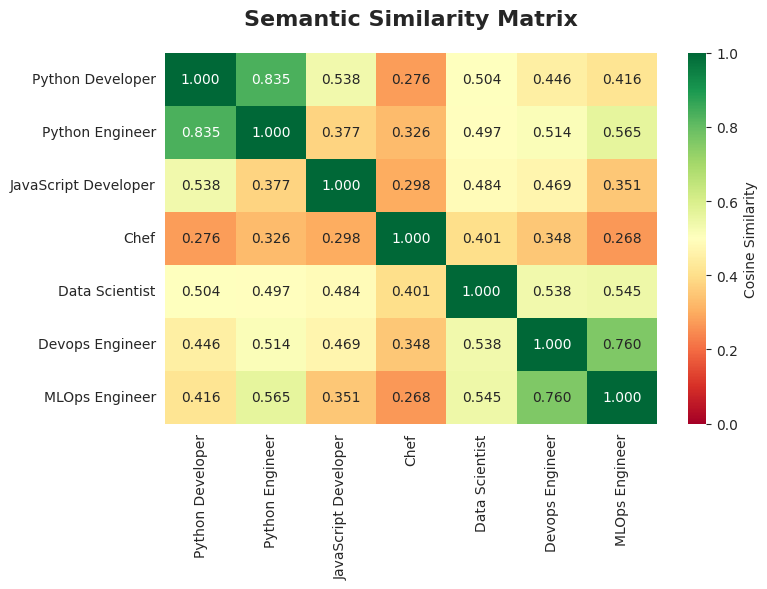


Observations:
  • 'Python Developer' and 'Python Engineer' are very similar (>0.9)
  • 'Python Developer' and 'JavaScript Developer' are moderately similar (~0.7)
  • 'Python Developer' and 'Chef' are very different (<0.3)


In [20]:
# Calculating the  similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=texts, yticklabels=texts, vmin=0, vmax=1,
            cbar_kws={'label': 'Cosine Similarity'})
plt.title('Semantic Similarity Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("  • 'Python Developer' and 'Python Engineer' are very similar (>0.9)")
print("  • 'Python Developer' and 'JavaScript Developer' are moderately similar (~0.7)")
print("  • 'Python Developer' and 'Chef' are very different (<0.3)")

## **Part 3: Generate Resume Embeddings**

In [21]:
# Sample a subset for faster processing (use all for production)
sample_size = 1000
df_sample = df.sample(n=min(sample_size, len(df)), random_state=42)

print(f"Processing {len(df_sample):,} resumes...")
print("This may take a few minutes...")

Processing 1,000 resumes...
This may take a few minutes...


In [22]:
# Generate embeddings for resumes
# We'll use the cleaned resume text
resume_texts = df_sample['Resume_clean'].tolist()

# Truncate very long resumes to fit model's max length
resume_texts_truncated = [text[:5000] for text in resume_texts]

# Generate embeddings (batch processing for efficiency)
print("Generating embeddings...")
resume_embeddings = model.encode(
    resume_texts_truncated,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\n✅ Generated {len(resume_embeddings):,} embeddings")
print(f"Shape: {resume_embeddings.shape}")
print(f"Memory: {resume_embeddings.nbytes / 1024**2:.2f} MB")

Generating embeddings...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]


✅ Generated 1,000 embeddings
Shape: (1000, 768)
Memory: 2.93 MB


In [23]:
# Add embeddings to dataframe
df_sample = df_sample.copy()
df_sample['embedding'] = list(resume_embeddings)

print("Embeddings added to dataframe")
print(f"\nDataframe shape: {df_sample.shape}")
print(f"Columns: {list(df_sample.columns)}")

Embeddings added to dataframe

Dataframe shape: (1000, 9)
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category', 'resume_length', 'word_count', 'avg_word_length', 'Resume_clean', 'embedding']


##  **Part 4: Analyze Semantic Similarity by Category**

In [24]:
# Calculate within-category similarity
# (How similar are resumes within the same category?)

category_similarities = {}

for category in df_sample['Category'].unique():
    # Get resumes in this category
    cat_mask = df_sample['Category'] == category
    cat_embeddings = np.stack(df_sample[cat_mask]['embedding'].values)

    if len(cat_embeddings) > 1:
        # Calculate pairwise similarities
        sim_matrix = cosine_similarity(cat_embeddings)

        # Get upper triangle (exclude diagonal)
        upper_tri = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]

        category_similarities[category] = {
            'mean': upper_tri.mean(),
            'std': upper_tri.std(),
            'count': len(cat_embeddings)
        }

# Display results
print("Within-Category Similarity:")
print("=" * 70)
for cat, stats in sorted(category_similarities.items(), key=lambda x: x[1]['mean'], reverse=True):
    print(f"{cat:30s}: {stats['mean']:.3f} ± {stats['std']:.3f} (n={stats['count']})")

Within-Category Similarity:
ACCOUNTANT                    : 0.766 ± 0.077 (n=50)
HR                            : 0.718 ± 0.096 (n=38)
CHEF                          : 0.679 ± 0.146 (n=49)
BUSINESS-DEVELOPMENT          : 0.663 ± 0.095 (n=48)
FINANCE                       : 0.654 ± 0.091 (n=48)
SALES                         : 0.654 ± 0.103 (n=54)
TEACHER                       : 0.631 ± 0.108 (n=49)
INFORMATION-TECHNOLOGY        : 0.613 ± 0.114 (n=59)
CONSTRUCTION                  : 0.602 ± 0.127 (n=49)
HEALTHCARE                    : 0.599 ± 0.106 (n=40)
DIGITAL-MEDIA                 : 0.584 ± 0.116 (n=44)
ENGINEERING                   : 0.568 ± 0.131 (n=42)
BANKING                       : 0.564 ± 0.130 (n=49)
PUBLIC-RELATIONS              : 0.562 ± 0.118 (n=35)
CONSULTANT                    : 0.555 ± 0.130 (n=42)
AVIATION                      : 0.548 ± 0.106 (n=43)
ADVOCATE                      : 0.539 ± 0.151 (n=53)
DESIGNER                      : 0.528 ± 0.116 (n=42)
BPO               

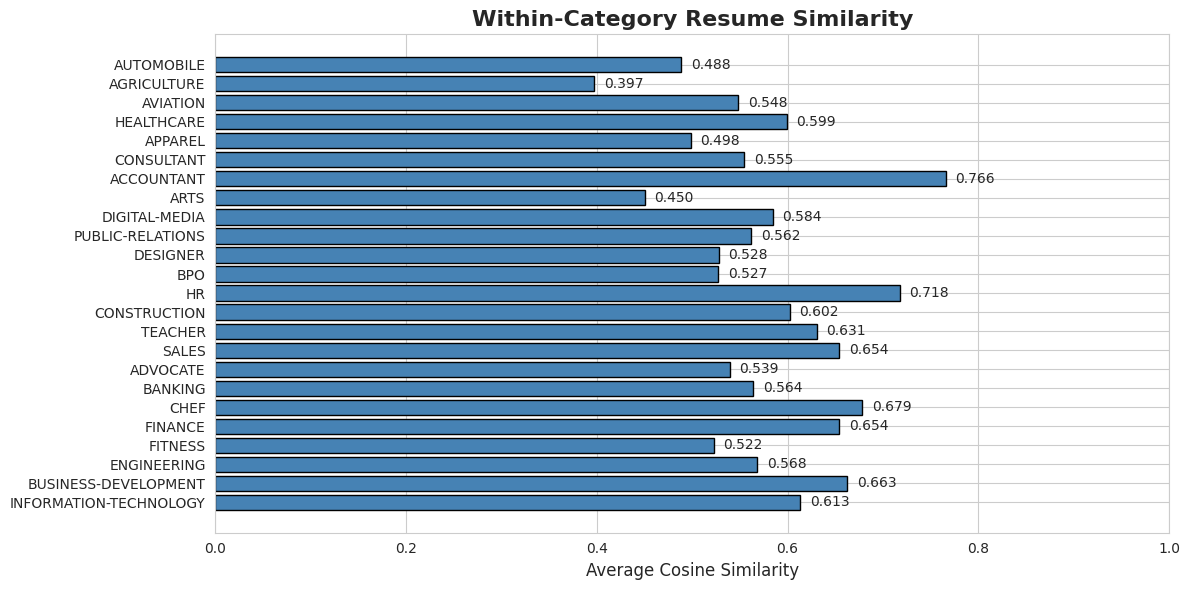


Insight: Higher similarity means resumes in that category are more homogeneous


In [26]:
# Visualize category similarities
cat_names = list(category_similarities.keys())
cat_means = [category_similarities[cat]['mean'] for cat in cat_names]

plt.figure(figsize=(12, 6))
plt.barh(cat_names, cat_means, color='steelblue', edgecolor='black')
plt.xlabel('Average Cosine Similarity', fontsize=12)
plt.title('Within-Category Resume Similarity', fontsize=16, fontweight='bold')
plt.xlim(0, 1)
for i, v in enumerate(cat_means):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

print("\nInsight: Higher similarity means resumes in that category are more homogeneous")

## **Part 5: Create Training Pairs for Fine-Tuning**

In [28]:
# Create training pairs with similarity labels
# We'll create:
# 1. Positive pairs: Same category (high similarity)
# 2. Negative pairs: Different categories (low similarity)

training_pairs = []

# For each category, create positive pairs
for category in df_sample['Category'].unique():
    cat_resumes = df_sample[df_sample['Category'] == category]['Resume_clean'].tolist()

    # Create pairs within category (positive examples)
    if len(cat_resumes) >= 2:
        for i in range(min(10, len(cat_resumes))):
            for j in range(i+1, min(i+3, len(cat_resumes))):
                training_pairs.append({
                    'text1': cat_resumes[i][:1000],  # Truncate for training
                    'text2': cat_resumes[j][:1000],
                    'similarity': 0.85,  # High similarity (same category)
                    'label': 'positive'
                })

# Create negative pairs (different categories)
categories = df_sample['Category'].unique()
for i in range(len(categories)):
    for j in range(i+1, len(categories)):
        cat1_resumes = df_sample[df_sample['Category'] == categories[i]]['Resume_clean'].tolist()
        cat2_resumes = df_sample[df_sample['Category'] == categories[j]]['Resume_clean'].tolist()

        # Sample a few pairs
        for k in range(min(5, len(cat1_resumes), len(cat2_resumes))):
            training_pairs.append({
                'text1': cat1_resumes[k][:1000],
                'text2': cat2_resumes[k][:1000],
                'similarity': 0.25,  # Low similarity (different categories)
                'label': 'negative'
            })

print(f"Created {len(training_pairs):,} training pairs")
print(f"Positive pairs: {sum(1 for p in training_pairs if p['label'] == 'positive'):,}")
print(f"Negative pairs: {sum(1 for p in training_pairs if p['label'] == 'negative'):,}")

Created 1,853 training pairs
Positive pairs: 473
Negative pairs: 1,380


In [29]:
# Convert to DataFrame
training_df = pd.DataFrame(training_pairs)

print("Training Data Sample:")
print("=" * 70)
print(training_df.head())

print(f"\nSimilarity distribution:")
print(training_df['similarity'].value_counts())

Training Data Sample:
                                               text1  \
0  information technology specialist(discountpcfi...   
1  information technology specialist(discountpcfi...   
2  corporate project manager career overview seas...   
3  corporate project manager career overview seas...   
4  information technology technician i summary ve...   

                                               text2  similarity     label  
0  corporate project manager career overview seas...        0.85  positive  
1  information technology technician i summary ve...        0.85  positive  
2  information technology technician i summary ve...        0.85  positive  
3  information technology specialist career overv...        0.85  positive  
4  information technology specialist career overv...        0.85  positive  

Similarity distribution:
similarity
0.25    1380
0.85     473
Name: count, dtype: int64


In [30]:
# Save training pairs
training_df.to_csv('bert_training_pairs.csv', index=False)
print("Training pairs saved to: data/bert_training_pairs.csv")

# Also save embeddings for later use
import pickle
with open('resume_embeddings.pkl', 'wb') as f:
    pickle.dump({
        'embeddings': resume_embeddings,
        'categories': df_sample['Category'].tolist(),
        'ids': df_sample.index.tolist()
    }, f)
print("Embeddings saved to: data/resume_embeddings.pkl")

Training pairs saved to: data/bert_training_pairs.csv
Embeddings saved to: data/resume_embeddings.pkl


## **Part 6: Test Base Model Performance**

In [31]:
# Test base model on our training pairs
print("Testing base model performance...")

# Sample some pairs for testing
test_pairs = training_df.sample(n=min(100, len(training_df)), random_state=42)

# Calculate actual similarities
predictions = []
for _, row in test_pairs.iterrows():
    emb1 = model.encode(row['text1'])
    emb2 = model.encode(row['text2'])
    sim = cosine_similarity([emb1], [emb2])[0][0]
    predictions.append(sim)

test_pairs['predicted_similarity'] = predictions

print("\n Base model predictions complete")

Testing base model performance...

 Base model predictions complete


In [32]:
# Analyze base model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test_pairs['similarity'], test_pairs['predicted_similarity'])
rmse = np.sqrt(mean_squared_error(test_pairs['similarity'], test_pairs['predicted_similarity']))

print("Base Model Performance:")
print("=" * 60)
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"\nExpected vs Predicted:")
print(test_pairs[['similarity', 'predicted_similarity', 'label']].head(10))

Base Model Performance:
Mean Absolute Error: 0.1876
Root Mean Squared Error: 0.2275

Expected vs Predicted:
      similarity  predicted_similarity     label
233         0.85              0.723340  positive
450         0.85              0.486186  positive
1240        0.25              0.302266  negative
1693        0.25              0.276990  negative
411         0.85              0.583432  positive
1336        0.25              0.568380  negative
1526        0.25              0.393272  negative
1222        0.25              0.524343  negative
1233        0.25              0.197911  negative
1436        0.25              0.382475  negative


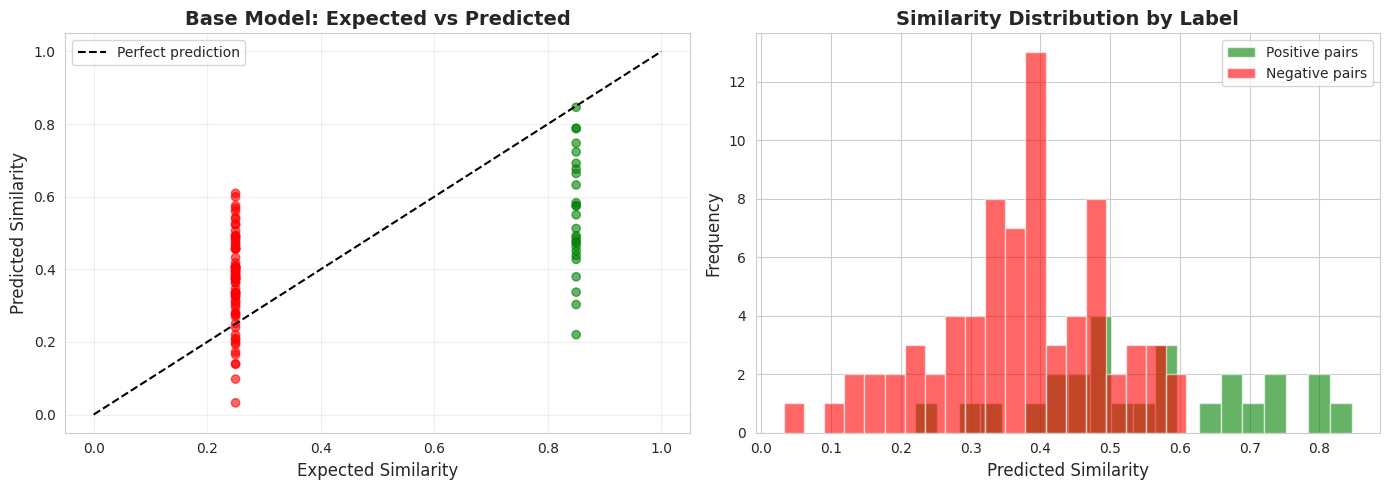


Goal: After fine-tuning, predictions should be closer to the diagonal line


In [34]:
# Visualize base model performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(test_pairs['similarity'], test_pairs['predicted_similarity'],
                alpha=0.6, c=test_pairs['label'].map({'positive': 'green', 'negative': 'red'}))
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect prediction')
axes[0].set_xlabel('Expected Similarity', fontsize=12)
axes[0].set_ylabel('Predicted Similarity', fontsize=12)
axes[0].set_title('Base Model: Expected vs Predicted', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution comparison
axes[1].hist(test_pairs[test_pairs['label']=='positive']['predicted_similarity'],
             bins=20, alpha=0.6, label='Positive pairs', color='green')
axes[1].hist(test_pairs[test_pairs['label']=='negative']['predicted_similarity'],
             bins=20, alpha=0.6, label='Negative pairs', color='red')
axes[1].set_xlabel('Predicted Similarity', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Similarity Distribution by Label', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nGoal: After fine-tuning, predictions should be closer to the diagonal line")

## **Key Takeaways**

### **What We Accomplished:**
1. Loaded pre-trained BERT model (all-mpnet-base-v2)
2. Generated 768-dimensional embeddings for resumes
3. Analyzed semantic similarity within categories
4. Created training pairs for fine-tuning
5. Tested base model performance

### **Key Insights:**
- BERT converts text to numerical vectors (embeddings)
- Cosine similarity measures semantic similarity (0-1)
- Resumes in same category have higher similarity
- Base model needs fine-tuning for better domain-specific matching

### **Data Created:**
- `bert_training_pairs.csv`: Training data for fine-tuning
- `resume_embeddings.pkl`: Pre-computed embeddings

---

## **Next Notebook**
**03_BERT_Fine_Tuning_and_Deployment.ipynb** - Fine-tune BERT and deploy for production

---